In [42]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.integrate import quad

Binomial - Computed Expectation: 4.9684
Binomial - Theoretical Mean: 5.0
Poisson - Computed Expectation: 2.9914
Poisson - Theoretical Mean: 3
Exponential - Computed Expectation: 0.49393246954582853
Exponential - Theoretical Mean: 0.5


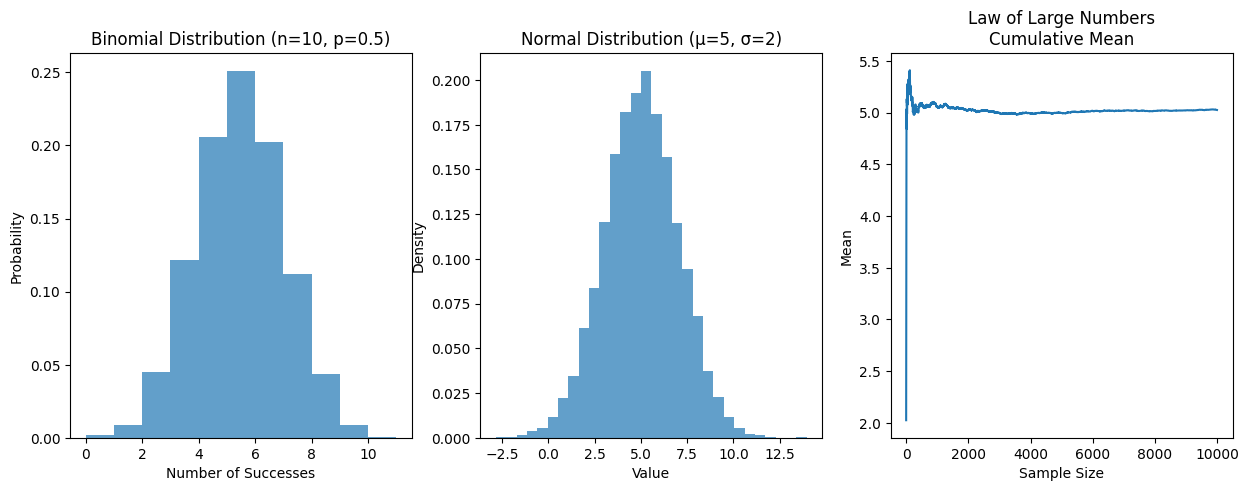

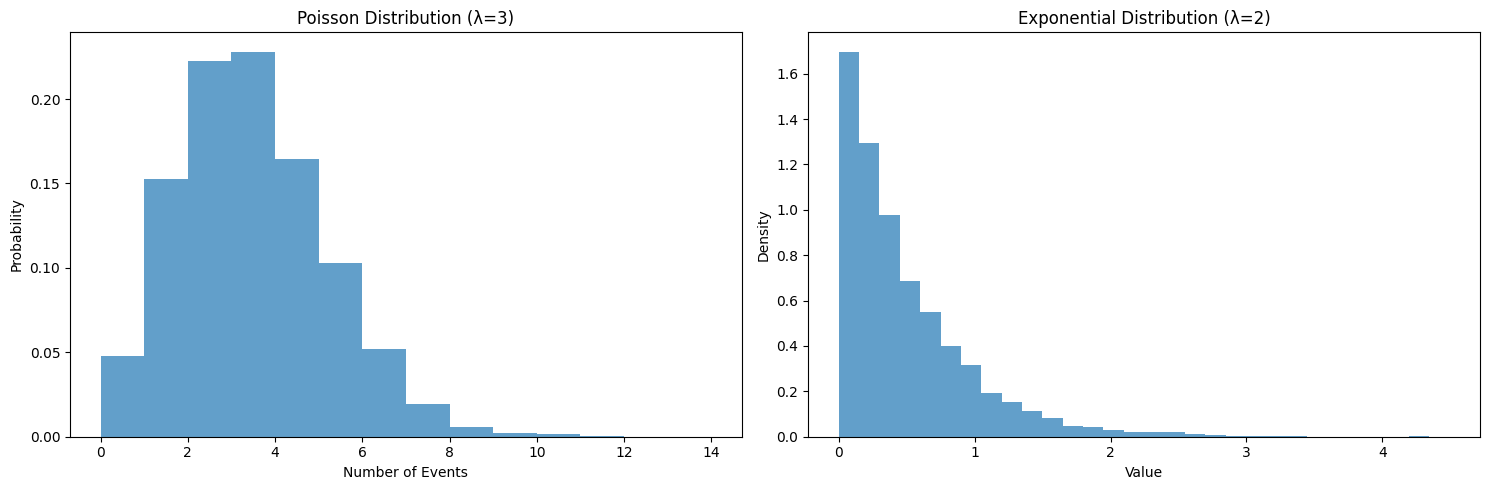

In [43]:
# Binomial Distribution
np.random.seed(42)
n, p = 10, 0.5
binomial_data = np.random.binomial(n, p, 10000)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.hist(binomial_data, bins=range(0, n+2), alpha=0.7, density=True)
plt.title(f'Binomial Distribution (n={n}, p={p})')
plt.xlabel('Number of Successes')
plt.ylabel('Probability')

computed_expectation = np.mean(binomial_data)
theoretical_mean = n * p
print(f"Binomial - Computed Expectation: {computed_expectation}")
print(f"Binomial - Theoretical Mean: {theoretical_mean}")

# Normal Distribution
mu, sigma = 5, 2
normal_data = np.random.normal(mu, sigma, 10000)

plt.subplot(132)
plt.hist(normal_data, bins=30, alpha=0.7, density=True)
plt.title(f'Normal Distribution (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Density')

cumulative_mean = np.cumsum(normal_data) / np.arange(1, len(normal_data) + 1)
plt.subplot(133)
plt.plot(cumulative_mean)
plt.title('Law of Large Numbers\nCumulative Mean')
plt.xlabel('Sample Size')
plt.ylabel('Mean')

# Poisson Distribution
lambda_param = 3
poisson_data = np.random.poisson(lambda_param, 10000)

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.hist(poisson_data, bins=range(0, max(poisson_data)+2), alpha=0.7, density=True)
plt.title(f'Poisson Distribution (λ={lambda_param})')
plt.xlabel('Number of Events')
plt.ylabel('Probability')

computed_poisson_expectation = np.mean(poisson_data)
theoretical_poisson_mean = lambda_param
print(f"Poisson - Computed Expectation: {computed_poisson_expectation}")
print(f"Poisson - Theoretical Mean: {theoretical_poisson_mean}")

# Exponential Distribution
rate = 2
exponential_data = np.random.exponential(1/rate, 10000)

plt.subplot(122)
plt.hist(exponential_data, bins=30, alpha=0.7, density=True)
plt.title(f'Exponential Distribution (λ={rate})')
plt.xlabel('Value')
plt.ylabel('Density')

computed_exponential_expectation = np.mean(exponential_data)
theoretical_exponential_mean = 1/rate
print(f"Exponential - Computed Expectation: {computed_exponential_expectation}")
print(f"Exponential - Theoretical Mean: {theoretical_exponential_mean}")

plt.tight_layout()
plt.show()


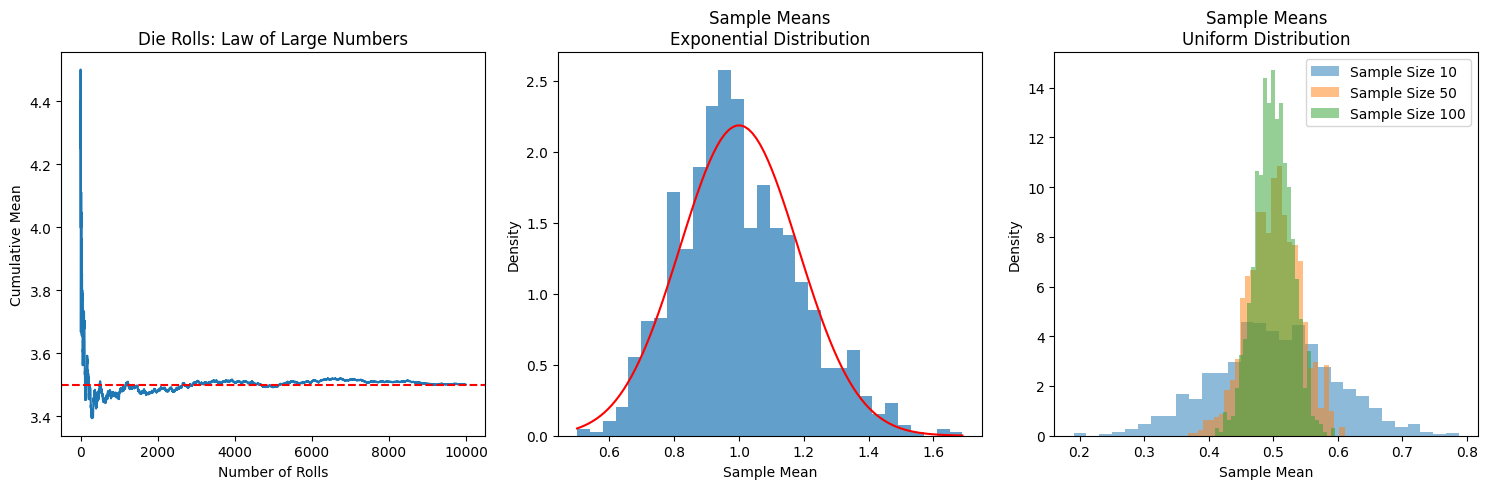

In [44]:
# Die Rolling - Law of Large Numbers
np.random.seed(42)
die_rolls = np.random.randint(1, 7, 10000)
cumulative_mean = np.cumsum(die_rolls) / np.arange(1, len(die_rolls) + 1)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.plot(cumulative_mean)
plt.title('Die Rolls: Law of Large Numbers')
plt.xlabel('Number of Rolls')
plt.ylabel('Cumulative Mean')
plt.axhline(y=3.5, color='r', linestyle='--')

# Central Limit Theorem - Exponential Distribution
lambda_param = 1
sample_sizes = 1000
sample_means = [np.mean(np.random.exponential(1/lambda_param, 30)) for _ in range(sample_sizes)]

plt.subplot(132)
plt.hist(sample_means, bins=30, density=True, alpha=0.7)
plt.title('Sample Means\nExponential Distribution')
plt.xlabel('Sample Mean')
plt.ylabel('Density')

# Theoretical Normal Distribution
theoretical_mean = 1/lambda_param
theoretical_std = (1/lambda_param) / np.sqrt(30)
x = np.linspace(min(sample_means), max(sample_means), 100)
plt.plot(x, stats.norm.pdf(x, theoretical_mean, theoretical_std), 'r-')

# Uniform Distribution - CLT
uniform_sample_sizes = [10, 50, 100]
plt.subplot(133)
for size in uniform_sample_sizes:
    sample_means = [np.mean(np.random.uniform(0, 1, size)) for _ in range(1000)]
    plt.hist(sample_means, bins=30, density=True, alpha=0.5, label=f'Sample Size {size}')

plt.title('Sample Means\nUniform Distribution')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()

In [45]:
# Height Hypothesis Test
population_mean = 170
population_std = 10
sample_size = 50
sample_mean = 172

z_score = (sample_mean - population_mean) / (population_std / np.sqrt(sample_size))
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print("Height Hypothesis Test:")
print(f"Z-score: {z_score}")
print(f"p-value: {p_value}")
print("Reject null hypothesis" if p_value < 0.05 else "Fail to reject null hypothesis")

# T-test example
np.random.seed(42)
true_mean = 100
true_std = 15
sample_data = np.random.normal(true_mean, true_std, 30)

t_statistic, p_value = stats.ttest_1samp(sample_data, true_mean)

print("\nT-Test Example:")
print(f"Sample Mean: {np.mean(sample_data)}")
print(f"T-statistic: {t_statistic}")
print(f"p-value: {p_value}")
print("Reject null hypothesis" if p_value < 0.05 else "Fail to reject null hypothesis")

# Real-world data example (simulated)
heights = np.random.normal(170, 10, 100)
population_mean = 168

t_statistic, p_value = stats.ttest_1samp(heights, population_mean)

print("\nReal-world Heights Test:")
print(f"Sample Mean: {np.mean(heights)}")
print(f"T-statistic: {t_statistic}")
print(f"p-value: {p_value}")
print("Reject null hypothesis" if p_value < 0.05 else "Fail to reject null hypothesis")


Height Hypothesis Test:
Z-score: 1.4142135623730951
p-value: 0.157299207050285
Fail to reject null hypothesis

T-Test Example:
Sample Mean: 97.17779656223442
T-statistic: -1.1450173670383383
p-value: 0.26156414618801166
Fail to reject null hypothesis

Real-world Heights Test:
Sample Mean: 169.68433623850532
T-statistic: 1.7657348352844104
p-value: 0.08052332449613372
Fail to reject null hypothesis


In [46]:
def f(x):
    return np.log(x) + x**3

def df_analytical(x):
    return 1/x + 3*x**2

def g(x, y):
    return x**3 + y**3 + x*y

def partial_x(x, y, h):
    return (g(x + h, y) - g(x - h, y)) / (2 * h)

def partial_y(x, y, h):
    return (g(x, y + h) - g(x, y - h)) / (2 * h)

def h(x, y):
    return np.sin(x) * np.cos(y)

def h_gradient_analytical(x, y):
    return np.cos(x) * np.cos(y), -np.sin(x) * np.sin(y)

# Problem 4a: Derivative of f(x)
x = 2
h = 0.01
numerical_derivative = (f(x + h) - f(x - h)) / (2 * h)
analytical_derivative = df_analytical(x)

print("Problem 4a: Derivative of f(x)")
print(f"Numerical Derivative at x = {x}: {numerical_derivative}")
print(f"Analytical Derivative at x = {x}: {analytical_derivative}")

# Problem 4b: Partial Derivatives
x, y = 1, 2
h = 0.01
partial_x_value = partial_x(x, y, h)
partial_y_value = partial_y(x, y, h)

print("\nProblem 4b: Partial Derivatives")
print(f"∂g/∂x at (x,y) = ({x},{y}): {partial_x_value}")
print(f"∂g/∂y at (x,y) = ({x},{y}): {partial_y_value}")

# Problem 4c: Gradient of h(x,y)
x, y = np.pi/4, np.pi/4
h_val = 0.01

# Numerical gradient for x
def h_x(x_val):
    return h(x_val, y)

# Numerical gradient for y
def h_y(y_val):
    return h(x, y_val)

# Compute numerical gradients
h_grad_x = (h_x(x + h_val) - h_x(x - h_val)) / (2 * h_val)
h_grad_y = (h_y(y + h_val) - h_y(y - h_val)) / (2 * h_val)

analytical_gradient = h_gradient_analytical(x, y)

print("\nProblem 4c: Gradient of h(x,y)")
print(f"Numerical Gradient: ({h_grad_x}, {h_grad_y})")
print(f"Analytical Gradient: {analytical_gradient}")


Problem 4a: Derivative of f(x)
Numerical Derivative at x = 2: 12.50010416672902
Analytical Derivative at x = 2: 12.5

Problem 4b: Partial Derivatives
∂g/∂x at (x,y) = (1,2): 5.000099999999907
∂g/∂y at (x,y) = (1,2): 13.000099999999826


TypeError: 'float' object is not callable

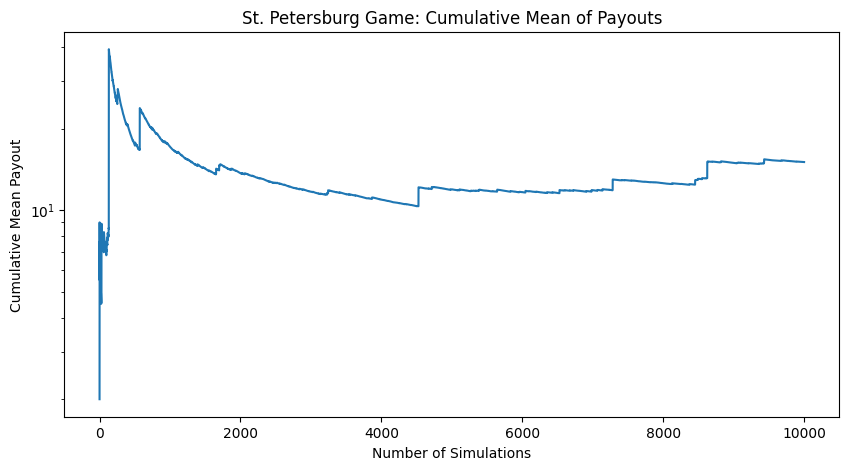

Final Cumulative Mean: 15.0382


In [47]:
np.random.seed(42)

def st_petersburg_game():
    flips = 0
    while True:
        flips += 1
        if np.random.random() < 0.5:
            return 2**flips

num_simulations = 10000
payouts = [st_petersburg_game() for _ in range(num_simulations)]

cumulative_mean = np.cumsum(payouts) / np.arange(1, len(payouts) + 1)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_mean)
plt.title('St. Petersburg Game: Cumulative Mean of Payouts')
plt.xlabel('Number of Simulations')
plt.ylabel('Cumulative Mean Payout')
plt.yscale('log')
plt.show()

print(f"Final Cumulative Mean: {cumulative_mean[-1]}")

# Because payout does not converge, there is no fair price for this game
# In real world scenarios this has a few implications
# You cannot price something solely based on the expected payout
# An real world application of exploding moments could be insurance
# When paying for insurance there are basically an infinite number of outcomes to consider
# However pricing the insurance based on the expected payout of all the possibilites is unreasonable
# This leads to a fair price problem similar to St. Petersburg's paradox

Monte Carlo Integration Result: 0.8949492494458715
Analytical Integration Result: 0.8820813907624215


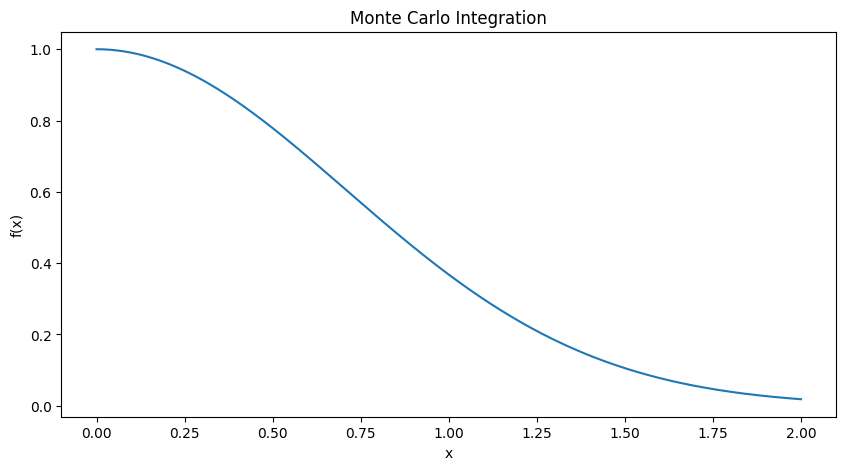


π Estimation: 3.144
Actual π: 3.141592653589793


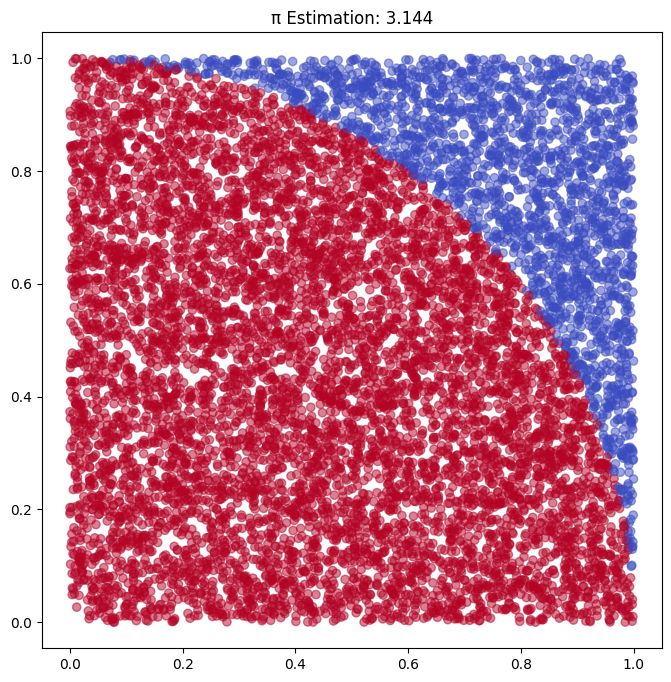


Monte Carlo Simulation of Sum of Random Variables:
Simulated Mean: 1.5482744106845334
Simulated Variance: 1.1968260636249184
Theoretical Mean: 1.5
Theoretical Variance: 1.0833333333333333


In [48]:
np.random.seed(42)

# Problem 6a: Monte Carlo Integration
def f(x):
    return np.exp(-x**2)

def monte_carlo_integration(func, a, b, num_samples):
    x = np.random.uniform(a, b, num_samples)
    y = func(x)
    integral = (b - a) * np.mean(y)
    return integral

num_samples = 10000
a, b = 0, 2
mc_integral = monte_carlo_integration(f, a, b, num_samples)

# Analytical integration for comparison
analytical_integral, _ = quad(f, a, b)

print(f"Monte Carlo Integration Result: {mc_integral}")
print(f"Analytical Integration Result: {analytical_integral}")

plt.figure(figsize=(10, 5))
x_plot = np.linspace(a, b, 200)
plt.plot(x_plot, f(x_plot), label='f(x) = e^(-x²)')
plt.title('Monte Carlo Integration')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

# Problem 6b: Estimating π
def estimate_pi(num_points):
    x = np.random.uniform(0, 1, num_points)
    y = np.random.uniform(0, 1, num_points)
    inside_circle = np.sum((x**2 + y**2) <= 1)
    pi_estimate = 4 * inside_circle / num_points
    return pi_estimate, x, y

num_points = 10000
pi_estimate, x, y = estimate_pi(num_points)

print(f"\nπ Estimation: {pi_estimate}")
print(f"Actual π: {np.pi}")

plt.figure(figsize=(8, 8))
plt.scatter(x, y, c=(x**2 + y**2 <= 1), cmap='coolwarm', alpha=0.5)
plt.title(f'π Estimation: {pi_estimate}')
plt.axis('equal')
plt.show()

# Problem 6c: Monte Carlo Simulation for Random Variables
uniform_samples = np.random.uniform(0, 1, 1000)
exponential_samples = np.random.exponential(1, 1000)

combined_samples = uniform_samples + exponential_samples

print("\nMonte Carlo Simulation of Sum of Random Variables:")
print(f"Simulated Mean: {np.mean(combined_samples)}")
print(f"Simulated Variance: {np.var(combined_samples)}")

# Theoretical calculation
theoretical_mean = (0 + 1/2) + (1/1)  # Mean of uniform + Mean of exponential
theoretical_variance = (1/12) + (1/1)  # Variance of uniform + Variance of exponential

print(f"Theoretical Mean: {theoretical_mean}")
print(f"Theoretical Variance: {theoretical_variance}")